In [1]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT = "/workspace/OCT2017"

TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")
TEST_DIR  = os.path.join(DATA_ROOT, "test")

IMG_SIZE   = 224
BATCH_SIZE = 32
MAX_PER_CLASS = 8000


2025-12-02 09:51:30.925077: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764669090.939960  314630 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764669090.944769  314630 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764669090.958164  314630 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764669090.958175  314630 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764669090.958178  314630 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
CLASS_NAMES = sorted(
    [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
)

NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

train_filepaths = []
train_labels    = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(TRAIN_DIR, class_name)

    files = [
        os.path.join(class_dir, f)
        for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))
    ]

    print(f"{class_name}: found {len(files)} images")

    random.shuffle(files)
    files = files[:MAX_PER_CLASS]

    train_filepaths.extend(files)
    train_labels.extend([class_idx] * len(files))

train_filepaths = np.array(train_filepaths)
train_labels    = np.array(train_labels)

print("Balanced train images:", len(train_filepaths))


Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Number of classes: 4
CNV: found 31427 images
DME: found 10939 images
DRUSEN: found 8017 images
NORMAL: found 26114 images
Balanced train images: 32000


In [3]:
def collect_filepaths_and_labels(base_dir, class_names):
    filepaths, labels = [], []
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, class_name)
        files = [
            os.path.join(class_dir, f)
            for f in os.listdir(class_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff"))
        ]
        filepaths.extend(files)
        labels.extend([class_idx] * len(files))
        print(f"{base_dir} | {class_name}: {len(files)}")
    return np.array(filepaths), np.array(labels)

val_filepaths,  val_labels  = collect_filepaths_and_labels(VAL_DIR, CLASS_NAMES)
test_filepaths, test_labels = collect_filepaths_and_labels(TEST_DIR, CLASS_NAMES)

print("Val images:", len(val_filepaths))
print("Test images:", len(test_filepaths))


/workspace/OCT2017/val | CNV: 8
/workspace/OCT2017/val | DME: 8
/workspace/OCT2017/val | DRUSEN: 8
/workspace/OCT2017/val | NORMAL: 8
/workspace/OCT2017/test | CNV: 242
/workspace/OCT2017/test | DME: 242
/workspace/OCT2017/test | DRUSEN: 242
/workspace/OCT2017/test | NORMAL: 242
Val images: 32
Test images: 968


In [4]:
clahe = cv2.createCLAHE(clipLimit=1.08, tileGridSize=(4,4))

def apply_clahe_np(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    cl = clahe.apply(l)  # apply CLAHE on L channel only

    merged = cv2.merge((cl, a, b))
    rgb = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    # Just scale to [0,1], no Z-score
    rgb = rgb.astype(np.float32) / 255.0

    return rgb



def load_and_preprocess(path, label):
    def _load_py(path_str):
        img = cv2.imread(path_str.decode("utf-8"))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = apply_clahe_np(img)
        return img

    img = tf.numpy_function(_load_py, [path], tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))

    return img, label


In [5]:
def make_dataset(filepaths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(len(filepaths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_filepaths, train_labels, shuffle=True)
val_ds   = make_dataset(val_filepaths,  val_labels)
test_ds  = make_dataset(test_filepaths, test_labels)

train_ds, val_ds, test_ds


I0000 00:00:1764669093.538962  314630 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79196 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:44:00.0, compute capability: 8.0


(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

In [6]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),
        layers.RandomContrast(0.03),
    ],
    name="data_augmentation",
)


In [7]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")

x = data_augmentation(inputs)

# ---- Convolution Blocks ----

# Block 1
x = layers.Conv2D(64, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 2
x = layers.Conv2D(128, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 3
x = layers.Conv2D(256, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 4
x = layers.Conv2D(512, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 5
x = layers.Conv2D(512, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# ---- Dense Head ----
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.6)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

cnn_model = models.Model(inputs, outputs, name="Custom_CNN_OCT")

cnn_model.summary()


Model: "Custom_CNN_OCT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,049,028 (15.45 MB)

 Trainable params: 4,046,084 (15.43 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [8]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(3.03e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_cnn_model_clahe_optuna_tuned.keras", monitor="val_loss", save_best_only=True),
]

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=callbacks
)


Epoch 1/35


I0000 00:00:1764669100.103413  315034 cuda_dnn.cc:529] Loaded cuDNN version 90800


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 56s 51ms/step - accuracy: 0.3881 - loss: 1.4372 - val_accuracy: 0.6562 - val_loss: 1.0066
Epoch 2/35
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.5490 - loss: 1.0448 - val_accuracy: 0.5312 - val_loss: 0.9966
Epoch 3/35
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 51s 51ms/step - accuracy: 0.6692 - loss: 0.8198 - val_accuracy: 0.4375 - val_loss: 1.2440
Epoch 4/35
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 51s 50ms/step - accuracy: 0.7390 - loss: 0.6761 - val_accuracy: 0.6250 - val_loss: 0.9835
Epoch 5/35
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 50s 50ms/step - accuracy: 0.7728 - loss: 0.5980 - val_accuracy: 0.6562 - val_loss: 0.7357
Epoch 6/35
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 51s 51ms/step - accuracy: 0.7976 - loss: 0.5439 - val_accuracy: 0.7812 - val_loss: 0.4079
Epoch 7/35
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.8099 - loss: 0.5127 - val_accuracy: 0.9062 - val_loss: 0.3165
Epoch 8/35
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 50s 50ms/step - accuracy: 0.8261 - loss: 0.47

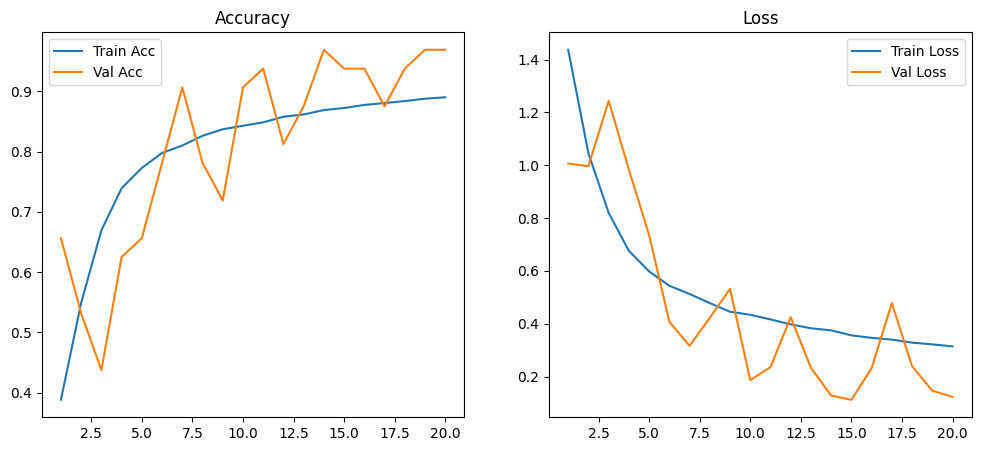

In [9]:
def plot_history(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label="Train Acc")
    plt.plot(epochs, val_acc, label="Val Acc")
    plt.title("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title("Loss")
    plt.legend()

    plt.show()

plot_history(history)


In [10]:
test_results = cnn_model.evaluate(test_ds, verbose=1)
print("\nKeras test metrics:")
for name, value in zip(cnn_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9731 - loss: 0.1110

Keras test metrics:
loss: 0.1110
compile_metrics: 0.9731


In [11]:
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_prob = cnn_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1-score: {macro_f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix:\n", cm)


2025-12-02 10:08:35.611048: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

Classification report:
              precision    recall  f1-score   support

         CNV     0.9786    0.9463    0.9622       242
         DME     0.9360    0.9669    0.9512       242
      DRUSEN     0.9877    0.9959    0.9918       242
      NORMAL     0.9833    0.9752    0.9793       242

    accuracy                         0.9711       968
   macro avg     0.9714    0.9711    0.9711       968
weighted avg     0.9714    0.9711    0.9711       968

Macro F1-score: 0.9711

Confusion matrix:
 [[229  11   2   0]
 [  4 234   0   4]
 [  1   0 241   0]
 [  0   5   1 236]]


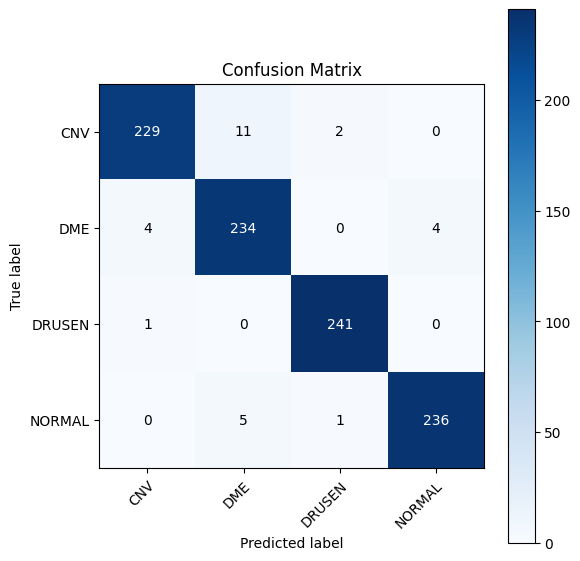

In [12]:
def plot_confusion_matrix(cm, class_names):
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names
    )
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    ax.set_title("Confusion Matrix")

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, CLASS_NAMES)
